In [1]:
import pandas as pd
import numpy as np
import mlflow 
from sklearn.preprocessing import MinMaxScaler
import joblib as jl
from pathlib import Path
PROJECT_ROOT = Path("/workspace")
DATA_DIR = PROJECT_ROOT / "data"
DATA_DIR.mkdir(exist_ok=True)

In [2]:
df=pd.read_csv("/workspace/data/Dataset.txt",delimiter=";")
print(df.head(5))

         Date      Time Global_active_power Global_reactive_power  Voltage  \
0  16/12/2006  17:24:00               4.216                 0.418  234.840   
1  16/12/2006  17:25:00               5.360                 0.436  233.630   
2  16/12/2006  17:26:00               5.374                 0.498  233.290   
3  16/12/2006  17:27:00               5.388                 0.502  233.740   
4  16/12/2006  17:28:00               3.666                 0.528  235.680   

  Global_intensity Sub_metering_1 Sub_metering_2  Sub_metering_3  
0           18.400          0.000          1.000            17.0  
1           23.000          0.000          1.000            16.0  
2           23.000          0.000          2.000            17.0  
3           23.000          0.000          1.000            17.0  
4           15.800          0.000          1.000            17.0  


/tmp/ipykernel_3077/4224544939.py:1: DtypeWarning: Columns (2,3,4,5,6,7) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv("/workspace/data/Dataset.txt",delimiter=";")


In [3]:
#cyclic encoding
def cyclic_encoding(df,col,period):
    df[f"{col}_sin"] = np.sin(2*np.pi*df[col]/period)
    df[f"{col}_cos"] = np.cos(2*np.pi*df[col]/period)
    return df

df['date_time'] = pd.to_datetime(df['Date'] + ' ' + df['Time'],dayfirst=True)
cols_to_process=df.select_dtypes(include='object').columns.difference(["Date","Time"])
df[cols_to_process]=df[cols_to_process].apply(
    lambda col: pd.to_numeric(col,errors='coerce')
)
df = df.dropna(subset=cols_to_process)  
df['date_time']=pd.to_datetime(df['date_time']) 
df["day_of_year"]=df["date_time"].dt.dayofyear.astype(float)
is_leap_year=df['date_time'].dt.is_leap_year
is_after=df['date_time'].dt.month>2
df.loc[is_leap_year&is_after,'day_of_year']-=1
df=cyclic_encoding(df,"day_of_year",365)
df['year'] = df['date_time'].apply(lambda x: x.year)
df['month'] = df['date_time'].dt.month
df['quarter'] = df['date_time'].dt.quarter
df=cyclic_encoding(df,"quarter",4)
df=cyclic_encoding(df,"month",12)

df=df.loc[:,['date_time','Global_active_power','Global_intensity' ,'Sub_metering_1','Sub_metering_2','Sub_metering_3','year','quarter_sin','quarter_cos','month_sin','month_cos','day_of_year_sin','day_of_year_cos']]
df.sort_values('date_time', inplace=True, ascending=True)
df = df.reset_index(drop=True)
df["weekday"]=df.apply(lambda row: row["date_time"].weekday(),axis=1)
df["weekday"] = (df["weekday"] <    5).astype(int)

array([[<Axes: title={'center': 'Global_active_power'}>,
        <Axes: title={'center': 'Global_intensity'}>],
       [<Axes: title={'center': 'Sub_metering_1'}>,
        <Axes: title={'center': 'Sub_metering_2'}>],
       [<Axes: title={'center': 'Sub_metering_3'}>, <Axes: >]],
      dtype=object)

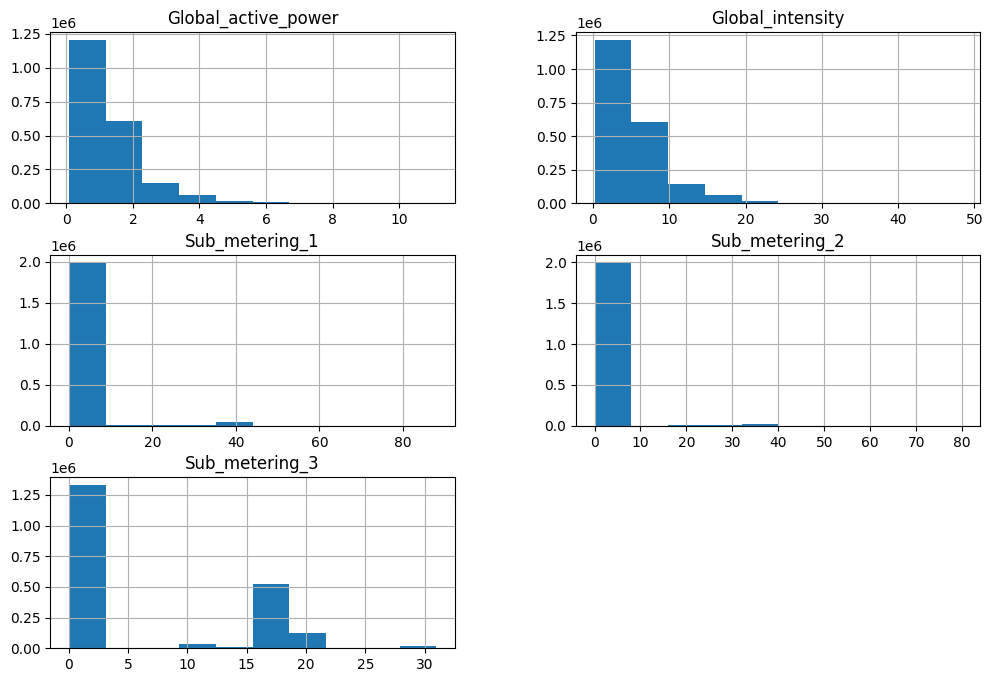

In [4]:
df[['Global_active_power',
    'Global_intensity',
    'Sub_metering_1',
    'Sub_metering_2',
    'Sub_metering_3']].hist(figsize=(12,8))

In [5]:
print(df.shape)
print(df.head(5))
dataset = df.select_dtypes(include='number').values #numpy.ndarray
dataset = dataset.astype('float32')
print(dataset.shape)

(2049280, 14)
            date_time  Global_active_power  Global_intensity  Sub_metering_1  \
0 2006-12-16 17:24:00                4.216              18.4             0.0   
1 2006-12-16 17:25:00                5.360              23.0             0.0   
2 2006-12-16 17:26:00                5.374              23.0             0.0   
3 2006-12-16 17:27:00                5.388              23.0             0.0   
4 2006-12-16 17:28:00                3.666              15.8             0.0   

   Sub_metering_2  Sub_metering_3  year   quarter_sin  quarter_cos  \
0             1.0            17.0  2006 -2.449294e-16          1.0   
1             1.0            16.0  2006 -2.449294e-16          1.0   
2             2.0            17.0  2006 -2.449294e-16          1.0   
3             1.0            17.0  2006 -2.449294e-16          1.0   
4             1.0            17.0  2006 -2.449294e-16          1.0   

      month_sin  month_cos  day_of_year_sin  day_of_year_cos  weekday  
0 -2.449294e

In [6]:
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()
#-----------------------------------------------------------------------------------
series = dataset.astype("float32")
split_1 = int(0.7 * len(series))
split_2=int(0.8 * len(series))
train_series = series[:split_1]
val_series=series[split_1:split_2]
test_series  = series[split_2:]

train_series[:,:5]= np.log1p(train_series[:,:5])
test_series[:,:5]=np.log1p(test_series[:,:5])
val_series[:,:5]=np.log1p(val_series[:,:5])

train_series_X= train_series
train_series_y= train_series[:,0].reshape(-1,1)
test_series_X= test_series
test_series_y= test_series[:,0].reshape(-1,1)
val_series_X= val_series
val_series_y= val_series[:,0].reshape(-1,1)

train_series_X = scaler_X.fit_transform(train_series_X)
train_series_y = scaler_y.fit_transform(train_series_y)
val_series_X = scaler_X.transform(val_series_X)
val_series_y = scaler_y.transform(val_series_y)
test_series_X =scaler_X.transform(test_series_X)
test_series_y =scaler_y.transform(test_series_y)


In [8]:
mlflow.set_tracking_uri(
    f"file://{PROJECT_ROOT / 'mlruns'}"
)
with mlflow.start_run():
    mlflow.set_tag("stage", "preprocessing")

    # save data
    jl.dump(scaler_X,DATA_DIR / "scaler_X.pkl")
    jl.dump(scaler_y,DATA_DIR / "scaler_y.pkl")
    pd.to_pickle(train_series_X,DATA_DIR / "train_X.pkl")
    pd.to_pickle(train_series_y,DATA_DIR / "train_y.pkl")
    pd.to_pickle(test_series_X,DATA_DIR / "test_X.pkl")
    pd.to_pickle(test_series_y,DATA_DIR / "test_y.pkl")
    pd.to_pickle(val_series_X,DATA_DIR / "val_X.pkl")
    pd.to_pickle(val_series_y,DATA_DIR / "val_y.pkl")

    mlflow.log_artifact(DATA_DIR / "scaler_X.pkl","data")
    mlflow.log_artifact(DATA_DIR / "scaler_y.pkl","data")
    mlflow.log_artifact(DATA_DIR / "train_X.pkl", "data")
    mlflow.log_artifact(DATA_DIR / "train_y.pkl", "data")
    mlflow.log_artifact(DATA_DIR / "test_X.pkl", "data")
    mlflow.log_artifact(DATA_DIR / "test_y.pkl", "data")
    mlflow.log_artifact(DATA_DIR / "val_X.pkl", "data")
    mlflow.log_artifact(DATA_DIR / "val_y.pkl", "data")


In [ ]:
import os

print("cwd:", os.getcwd())